In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()



Saving kaggle.json to kaggle.json


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 95.3MB/s]



In [7]:
!unzip -q chest-xray-pneumonia.zip


In [8]:
import os

for root, dirs, files in os.walk("chest_xray"):
    print(root, len(files))


chest_xray 0
chest_xray/chest_xray 1
chest_xray/chest_xray/train 1
chest_xray/chest_xray/train/NORMAL 1342
chest_xray/chest_xray/train/PNEUMONIA 3876
chest_xray/chest_xray/test 1
chest_xray/chest_xray/test/NORMAL 234
chest_xray/chest_xray/test/PNEUMONIA 390
chest_xray/chest_xray/val 1
chest_xray/chest_xray/val/NORMAL 9
chest_xray/chest_xray/val/PNEUMONIA 9
chest_xray/train 0
chest_xray/train/NORMAL 1341
chest_xray/train/PNEUMONIA 3875
chest_xray/__MACOSX 1
chest_xray/__MACOSX/chest_xray 3
chest_xray/__MACOSX/chest_xray/train 3
chest_xray/__MACOSX/chest_xray/train/NORMAL 1342
chest_xray/__MACOSX/chest_xray/train/PNEUMONIA 3876
chest_xray/__MACOSX/chest_xray/test 3
chest_xray/__MACOSX/chest_xray/test/NORMAL 234
chest_xray/__MACOSX/chest_xray/test/PNEUMONIA 390
chest_xray/__MACOSX/chest_xray/val 1
chest_xray/__MACOSX/chest_xray/val/NORMAL 9
chest_xray/__MACOSX/chest_xray/val/PNEUMONIA 9
chest_xray/test 0
chest_xray/test/NORMAL 234
chest_xray/test/PNEUMONIA 390
chest_xray/val 0
chest_xray/

In [9]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "chest_xray/train"
val_dir   = "chest_xray/val"
test_dir  = "chest_xray/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

print(train_ds.class_names)


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


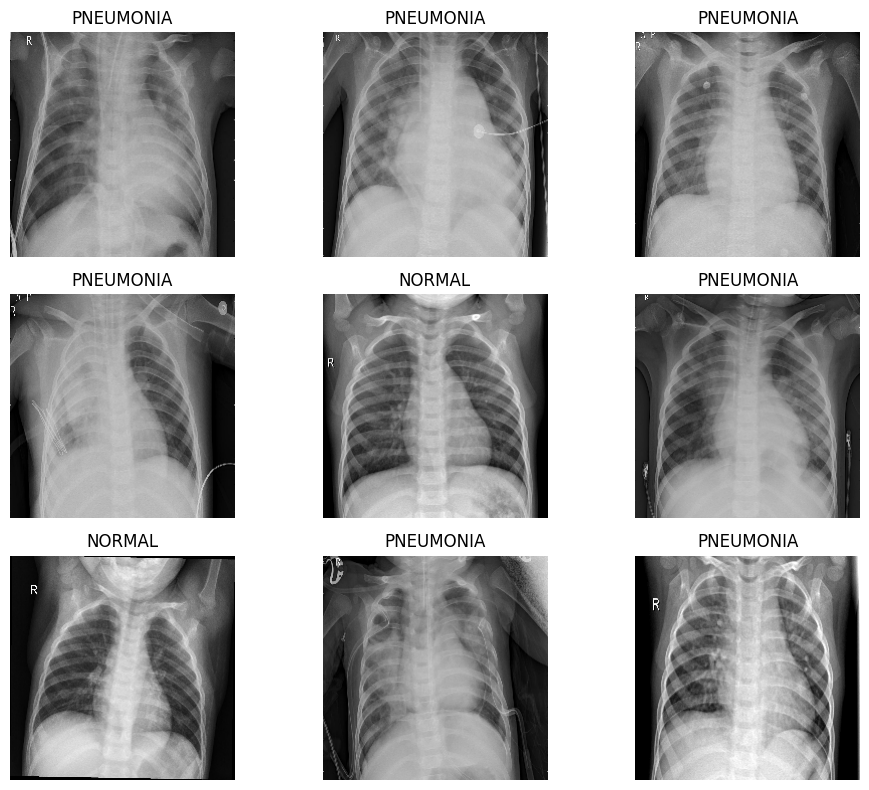

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [12]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,265 (19.48 MB)

 Trainable params: 5,107,265 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)


In [14]:
import tensorflow as tf

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 191ms/step - accuracy: 0.8696 - loss: 0.3000 - precision: 0.8845 - recall: 0.9484 - val_accuracy: 0.7500 - val_loss: 0.3033 - val_precision: 0.8333 - val_recall: 0.6250
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.9536 - loss: 0.1290 - precision: 0.9676 - recall: 0.9701 - val_accuracy: 0.9375 - val_loss: 0.1876 - val_precision: 0.8889 - val_recall: 1.0000
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 185ms/step - accuracy: 0.9647 - loss: 0.0935 - precision: 0.9775 - recall: 0.9750 - val_accuracy: 1.0000 - val_loss: 0.1073 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 188ms/step - accuracy: 0.9707 - loss: 0.0807 - precision: 0.9806 - recall: 0.9799 - val_accuracy: 1.0000 - val_loss: 0.0630 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9730 - loss: 0.0740 - precision: 0.9829 - recall: 0.9806 - val_accuracy: 0.7500

In [15]:
import numpy as np

cnn_results = cnn_model.evaluate(test_ds, verbose=1)
print("\nBaseline CNN — Test metrics")
for name, value in zip(cnn_model.metrics_names, cnn_results):
    print(f"{name:12s}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8013 - loss: 1.0464 - precision: 0.7618 - recall: 0.9923

Baseline CNN — Test metrics
loss        : 1.0464
compile_metrics: 0.8013


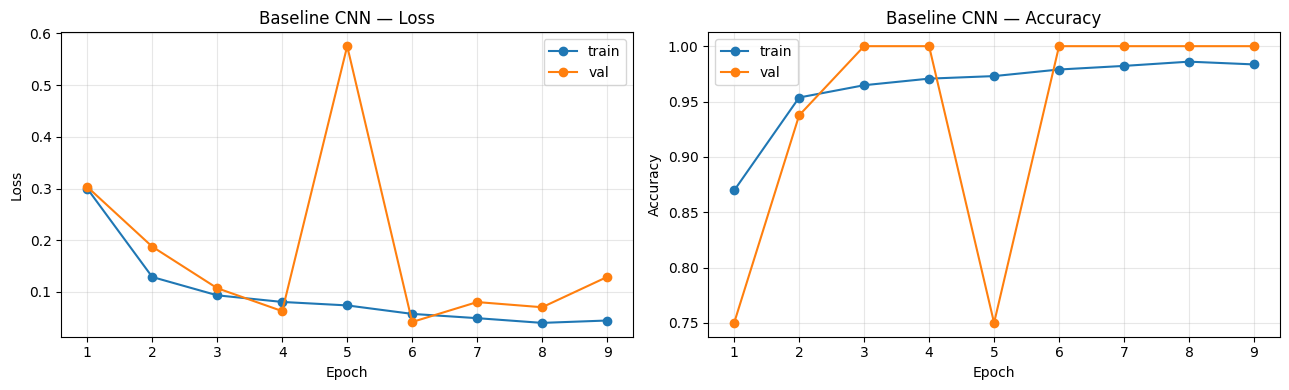

In [16]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, hist["loss"], "o-", label="train")
    axes[0].plot(epochs, hist["val_loss"], "o-", label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], "o-", label="train")
    axes[1].plot(epochs, hist["val_accuracy"], "o-", label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(cnn_history, "Baseline CNN")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step


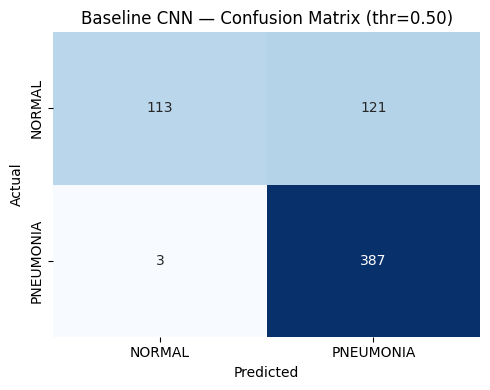

              precision    recall  f1-score   support

      NORMAL     0.9741    0.4829    0.6457       234
   PNEUMONIA     0.7618    0.9923    0.8619       390

    accuracy                         0.8013       624
   macro avg     0.8680    0.7376    0.7538       624
weighted avg     0.8414    0.8013    0.7808       624

ROC-AUC: 0.9007
Missed pneumonia cases (FN): 3   |   False alarms (FP): 121


In [17]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns

class_names = ["NORMAL", "PNEUMONIA"]

# test_ds was built with shuffle=False, so label order is stable
y_true = np.concatenate([y.numpy() for _, y in test_ds])

cnn_probs = cnn_model.predict(test_ds, verbose=1).ravel()
cnn_preds = (cnn_probs >= 0.5).astype(int)

def show_results(y_true, y_prob, title, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title(f"{title} (thr={threshold:.2f})")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 4))
    tn, fp, fn, tp = cm.ravel()
    print(f"Missed pneumonia cases (FN): {fn}   |   False alarms (FP): {fp}")

show_results(y_true, cnn_probs, "Baseline CNN — Confusion Matrix")


Transfer Learning


In [18]:
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# 80/20 split out of the 5216 training images (the original val/ has only 16)
train_ds_new = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/train",
    validation_split=0.2, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="rgb", shuffle=True
)

val_ds_new = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/train",
    validation_split=0.2, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, color_mode="rgb", shuffle=False
)

# class weights — dataset is ~3:1 imbalanced toward PNEUMONIA
train_labels = np.concatenate([y.numpy() for _, y in train_ds_new])
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=train_labels)
class_weights = {0: float(weights[0]), 1: float(weights[1])}
print("Class weights:", class_weights)

train_ds_new = train_ds_new.cache().prefetch(AUTOTUNE)
val_ds_new   = val_ds_new.cache().prefetch(AUTOTUNE)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Class weights: {0: 1.9107142857142858, 1: 0.6772151898734177}


In [19]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

base_model = tf.keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False          # freeze for feature extraction

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg16.preprocess_input(x)
features = base_model(x, training=False)          # keep this ref for Grad-CAM later
x = layers.GlobalAveragePooling2D()(features)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

tl_model = models.Model(inputs, outputs, name="vgg16_transfer")
tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     65,664 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1)
]

tl_history = tl_model.fit(
    train_ds_new,
    validation_data=val_ds_new,
    epochs=12,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 326ms/step - accuracy: 0.8572 - auc: 0.9238 - loss: 0.4103 - precision: 0.9490 - recall: 0.8523 - val_accuracy: 0.8773 - val_auc: 0.0000e+00 - val_loss: 0.3179 - val_precision: 1.0000 - val_recall: 0.8773 - learning_rate: 0.0010
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.9224 - auc: 0.9762 - loss: 0.1939 - precision: 0.9739 - recall: 0.9195 - val_accuracy: 0.8744 - val_auc: 0.0000e+00 - val_loss: 0.3604 - val_precision: 1.0000 - val_recall: 0.8744 - learning_rate: 0.0010
Epoch 3/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - accuracy: 0.9322 - auc: 0.9800 - loss: 0.1764 - precision: 0.9778 - recall: 0.9292 - val_accuracy: 0.9099 - val_auc: 0.0000e+00 - val_loss: 0.2413 - val_precision: 1.0000 - val_recall: 0.9099 - learning_rate: 0.0010
Epoch 4/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9372 - auc: 0.9850 - loss: 0.1505 - precision: 0.9822 - recall: 0.9318 - val_accuracy: 0.9118 - val_auc: 0.0000e

In [21]:
base_model.trainable = True

# freeze everything except the last VGG16 block
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")

print("Trainable layers:", [l.name for l in base_model.layers if l.trainable])

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # very low LR — critical
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")]
)

ft_history = tl_model.fit(
    train_ds_new,
    validation_data=val_ds_new,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Trainable layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 203ms/step - accuracy: 0.9631 - auc: 0.9945 - loss: 0.0875 - precision: 0.9886 - recall: 0.9611 - val_accuracy: 0.9482 - val_auc: 0.0000e+00 - val_loss: 0.1420 - val_precision: 1.0000 - val_recall: 0.9482 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.9756 - auc: 0.9972 - loss: 0.0612 - precision: 0.9934 - recall: 0.9734 - val_accuracy: 0.9837 - val_auc: 0.0000e+00 - val_loss: 0.0446 - val_precision: 1.0000 - val_recall: 0.9837 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.9758 - auc: 0.9967 - loss: 0.0657 - precision: 0.9931 - recall: 0.9740 - val_accuracy: 0.9837 - val_auc: 0.0000e+00 - val_loss: 0.0381 - val_precision: 1.0000 - val_recall: 0.9837 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.9768 - auc: 0.9973

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 334ms/step - accuracy: 0.8429 - auc: 0.9207 - loss: 0.7737 - precision: 0.8029 - recall: 0.9923

VGG16 Transfer — Test metrics
loss        : 0.7737
compile_metrics: 0.8429


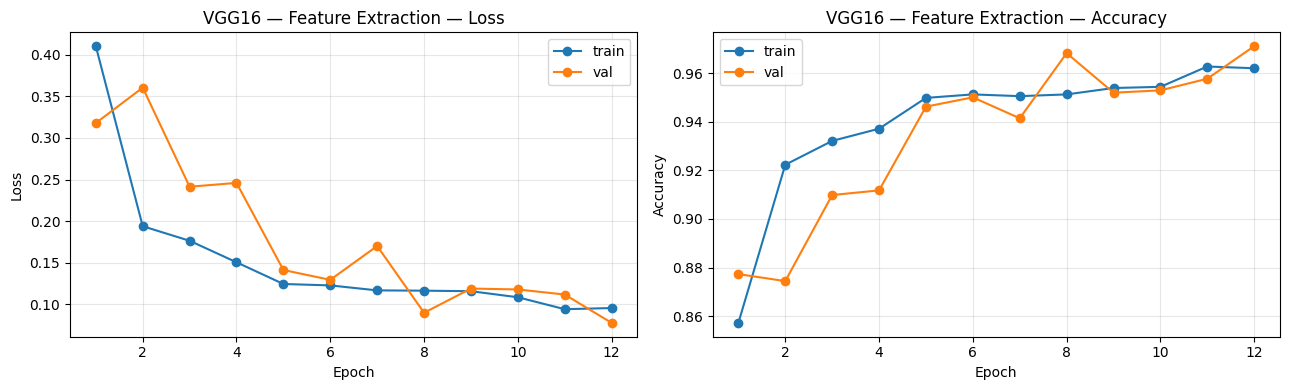

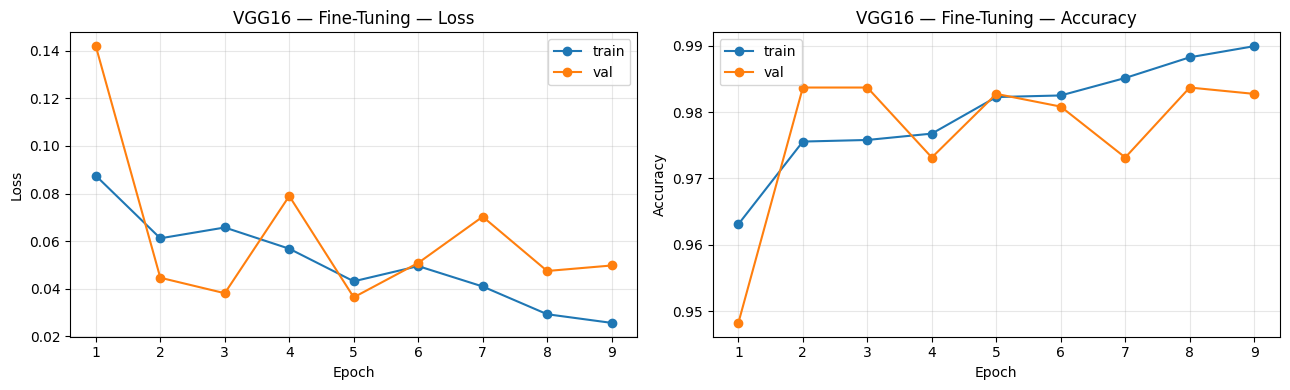

In [22]:
tl_results = tl_model.evaluate(test_ds, verbose=1)
print("\nVGG16 Transfer — Test metrics")
for name, value in zip(tl_model.metrics_names, tl_results):
    print(f"{name:12s}: {value:.4f}")

plot_history(tl_history, "VGG16 — Feature Extraction")
plot_history(ft_history, "VGG16 — Fine-Tuning")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 320ms/step


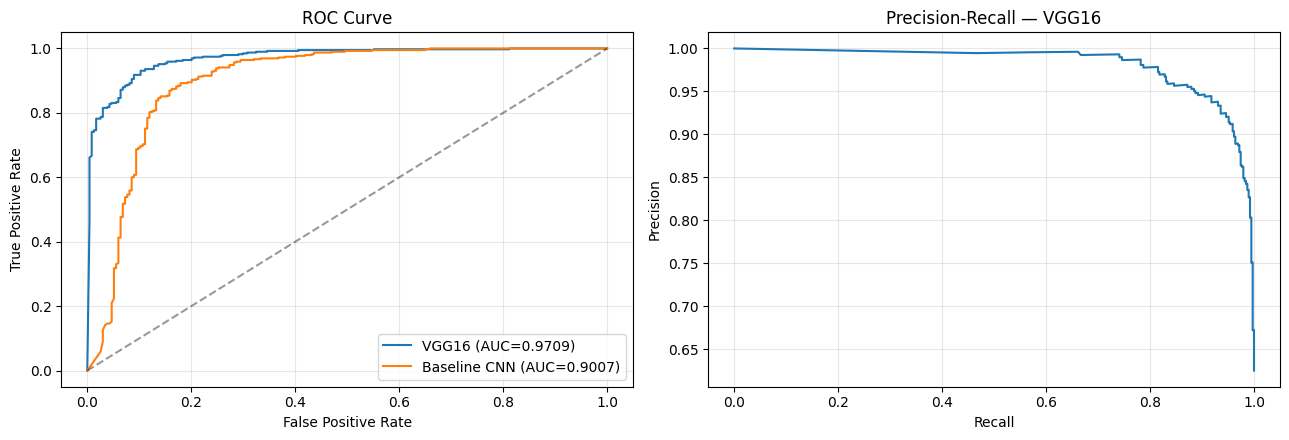

Best F1 threshold: 0.995  (F1=0.9357)


In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

tl_probs = tl_model.predict(test_ds, verbose=1).ravel()

fpr, tpr, _ = roc_curve(y_true, tl_probs)
prec, rec, thresholds = precision_recall_curve(y_true, tl_probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"VGG16 (AUC={auc(fpr, tpr):.4f})")
f2, t2, _ = roc_curve(y_true, cnn_probs)
axes[0].plot(f2, t2, label=f"Baseline CNN (AUC={auc(f2, t2):.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall — VGG16"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# pick the threshold with the best F1
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thresholds[np.argmax(f1_scores[:-1])]
print(f"Best F1 threshold: {best_thr:.3f}  (F1={f1_scores.max():.4f})")

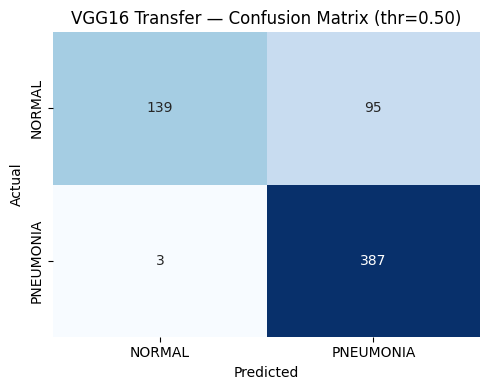

              precision    recall  f1-score   support

      NORMAL     0.9789    0.5940    0.7394       234
   PNEUMONIA     0.8029    0.9923    0.8876       390

    accuracy                         0.8429       624
   macro avg     0.8909    0.7932    0.8135       624
weighted avg     0.8689    0.8429    0.8320       624

ROC-AUC: 0.9709
Missed pneumonia cases (FN): 3   |   False alarms (FP): 95

--- With tuned threshold ---


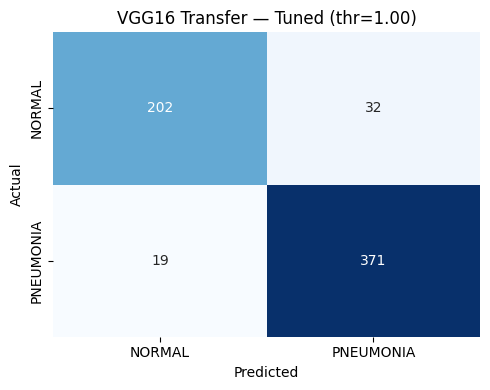

              precision    recall  f1-score   support

      NORMAL     0.9140    0.8632    0.8879       234
   PNEUMONIA     0.9206    0.9513    0.9357       390

    accuracy                         0.9183       624
   macro avg     0.9173    0.9073    0.9118       624
weighted avg     0.9181    0.9183    0.9178       624

ROC-AUC: 0.9709
Missed pneumonia cases (FN): 19   |   False alarms (FP): 32


In [24]:
show_results(y_true, tl_probs, "VGG16 Transfer — Confusion Matrix", threshold=0.5)
print("\n--- With tuned threshold ---")
show_results(y_true, tl_probs, "VGG16 Transfer — Tuned", threshold=float(best_thr))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Baseline CNN,0.8013,0.7618,0.9923,0.8619,0.9007
VGG16 Transfer,0.8429,0.8029,0.9923,0.8876,0.9709
VGG16 (thr=1.00),0.9183,0.9206,0.9513,0.9357,0.9709


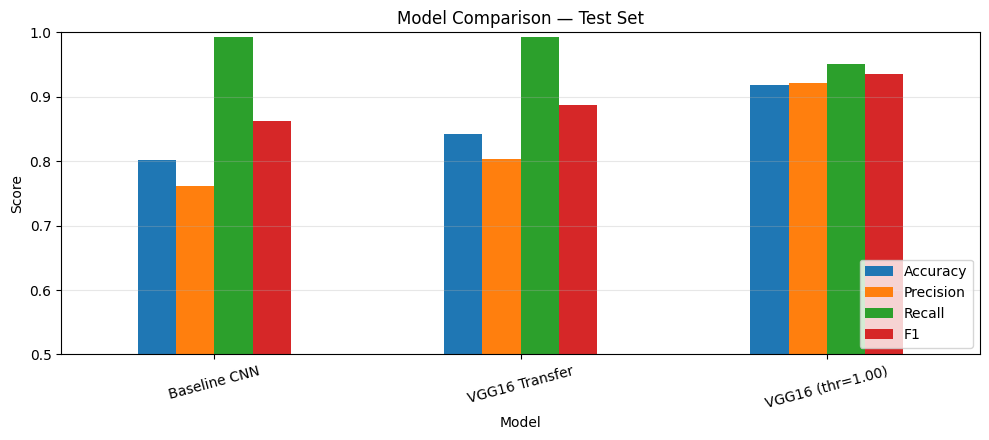

In [25]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def row(name, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
    }

comparison = pd.DataFrame([
    row("Baseline CNN", cnn_probs),
    row("VGG16 Transfer", tl_probs),
    row(f"VGG16 (thr={best_thr:.2f})", tl_probs, best_thr),
]).set_index("Model").round(4)

display(comparison)

comparison[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(10, 4.5), rot=15, ylim=(0.5, 1.0)
)
plt.title("Model Comparison — Test Set"); plt.ylabel("Score")
plt.legend(loc="lower right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_33']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


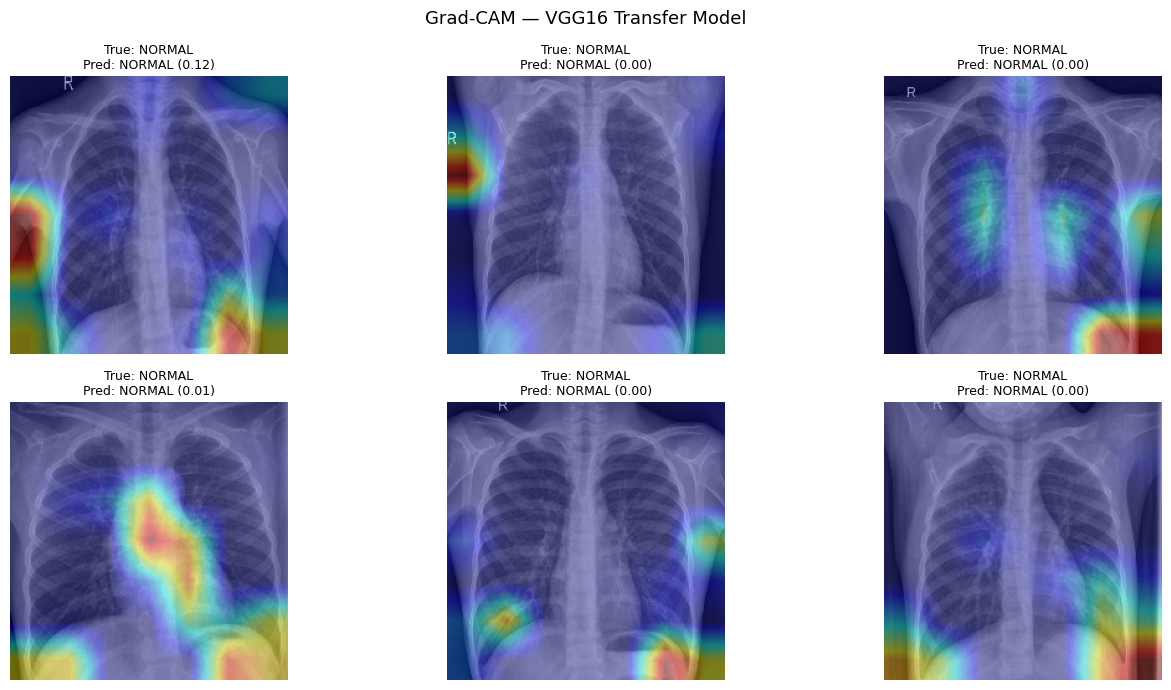

In [26]:
import cv2

grad_model = tf.keras.models.Model(tl_model.inputs, [features, tl_model.output])

def grad_cam(img_array):
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_array, training=False)
        tape.watch(conv_out)
        loss = pred[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_out[0] * pooled, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy(), float(pred[0][0])

# grab a batch from the test set
for images, labels in test_ds.take(1):
    batch_imgs, batch_lbls = images.numpy(), labels.numpy()
    break

plt.figure(figsize=(14, 7))
for i in range(6):
    img = batch_imgs[i]
    heatmap, prob = grad_cam(np.expand_dims(img, 0))

    hm = cv2.resize(heatmap, (224, 224))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(0.6 * img + 0.4 * hm)

    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay)
    plt.title(f"True: {class_names[batch_lbls[i]]}\nPred: {class_names[int(prob>=0.5)]} ({prob:.2f})",
              fontsize=9)
    plt.axis("off")

plt.suptitle("Grad-CAM — VGG16 Transfer Model", fontsize=13)
plt.tight_layout(); plt.show()

In [27]:
cnn_model.save("pneumonia_baseline_cnn.keras")
tl_model.save("pneumonia_vgg16_transfer.keras")

np.save("best_threshold.npy", np.array([best_thr]))
print("Saved both models.")

# from google.colab import files
# files.download("pneumonia_vgg16_transfer.keras")

Saved both models.
